In [1]:
!cd ..

# Experiment 1: Deformable 3D Gaussians on D-NeRF

This notebook documents the Google Colab workflow used to run Experiment 1 for the CS 547 final research project. The goal is to reproduce the original Deformable 3D Gaussians training pipeline on D-NeRF scenes, evaluate reconstruction quality using PSNR, and generate rendered outputs for qualitative comparison.

The notebook preserves setup attempts, dependency fixes, dataset acquisition steps, training runs, rendering commands, and visual comparisons so the experiment can be reviewed and reproduced.


## Verify GPU Runtime

This cell checks whether Google Colab has assigned an NVIDIA GPU. GPU availability is required because training and rendering Deformable 3D Gaussians relies on CUDA acceleration.


In [1]:
!nvidia-smi

Fri Apr 24 20:45:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Clone Forked Repository and Initialize Submodules

This cell clones the forked Deformable 3D Gaussians repository, switches to the working branch, and initializes submodules. The submodules are required because CUDA extensions such as `simple-knn` and differentiable rasterization are built separately.


In [2]:
!git clone https://github.com/YashPatel2395/CS_547_Deformable-3D-Gaussians-Public_pately1.git
%cd CS_547_Deformable-3D-Gaussians-Public_pately1
!git checkout original-work
!git submodule update --init --recursive

Cloning into 'CS_547_Deformable-3D-Gaussians-Public_pately1'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 176 (delta 28), reused 18 (delta 18), pack-reused 116 (from 1)
Receiving objects: 100% (176/176), 21.57 MiB | 23.23 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/CS_547_Deformable-3D-Gaussians-Public_pately1
Branch 'original-work' set up to track remote branch 'original-work' from 'origin'.
Switched to a new branch 'original-work'
Submodule 'submodules/depth-diff-gaussian-rasterization' (https://github.com/ingra14m/diff-gaussian-rasterization-extentions) registered for path 'submodules/depth-diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization'...
Clo

## Install Repository Requirements

This cell installs the Python dependencies listed by the repository. These packages provide the base libraries needed for training, rendering, image processing, and logging.


In [5]:
!pip install -r requirements.txt

Processing ./submodules/depth-diff-gaussian-rasterization
  Preparing metadata (setup.py) ... done
Processing ./submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Using cached plyfile-0.8.1-py3-none-any.whl.metadata (21 kB)
  Using cached imageio-2.27.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached dearpygui-2.3-cp312-cp312-manylinux1_x86_64.whl.metadata (13 kB)
  Using cached lpips-0.1.4-py3-none-any.whl.metadata (10 kB)
Using cached plyfile-0.8.1-py3-none-any.whl (28 kB)
Using cached imageio-2.27.0-py3-none-any.whl (3.4 MB)
Using cached dearpygui-2.3-cp312-cp312-manylinux1_x86_64.whl (2.7 MB)
Using cached lpips-0.1.4-py3-none-any.whl (53 kB)
  Created wheel for diff_gaussian_rasterization: filename=diff_gaussian_rasterization-0.0.0-cp312-cp312-linux_x86_64.whl size=3840903 sha256=d0e6578af304354259555ce2936dd9997ba7116a15b78edac09eb714e55deafd
  Stored in directory: /root/.cache/pip/wheels/0b/dd/49/644c6f64d75bd88dc5078df2b00a088524d3f434044454de9a
  error: subproce

## Install Build Helper

This cell installs `ninja`, which is used to compile native CUDA/C++ extensions more reliably in Colab.


In [6]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1
!pip install ninja

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.1 MB/s eta 0:00:00


## Build `simple-knn` CUDA Extension

This cell attempts to clean and build the `simple-knn` submodule. This extension is needed by the Gaussian initialization and nearest-neighbor distance computations.


In [7]:
%cd submodules/simple-knn
!python setup.py clean
!pip install . -v

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn
running clean
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Processing /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-g050qqfq/simple_knn.egg-info
  writing /tmp/pip-pip-egg-info-g050qqfq/simple_knn.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-pip-egg-info-g050qqfq/simple_knn.egg-info/dependency_links.txt
  writing top-level names to /tmp/pip-pip-egg-info-g050qqfq/simple_knn.egg-info/top_level.txt
  writing manifest file '/tmp/pip-pip-egg-info-g050qqfq/simple_knn.egg-info/SOURCES.txt'
  reading manifest file '/tmp/pip-pip-egg-info-g050qqfq/simple_knn.egg-info/SOURCES.txt'
  writing manifest file '/tmp/pip-pip-egg-info-g050qqfq/simple_knn.egg-info/SOURCES.txt'
  Preparing metadata (setup.py) ... done
  Running command python setup.py bdist_whe

## Enter `simple-knn` Source Directory

This cell moves into the `simple-knn` submodule directory so that source-level compatibility fixes and rebuild commands can be applied directly.


In [8]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn


## Apply Colab Build Fix for `simple-knn`

This cell inserts `#include <cfloat>` into `simple_knn.cu`. This fixes a CUDA compilation issue in the Colab environment where floating-point constants are not resolved correctly without the header.


In [10]:
!sed -i '1i #include <cfloat>' simple_knn.cu

## Rebuild Modified CUDA Extension

After applying the source fix, this cell rebuilds and installs the modified CUDA extension. A successful build confirms that the Colab environment can compile the project-specific native code.


In [11]:
!pip install . -v

Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Processing /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-g1_hhxdb/simple_knn.egg-info
  writing /tmp/pip-pip-egg-info-g1_hhxdb/simple_knn.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-pip-egg-info-g1_hhxdb/simple_knn.egg-info/dependency_links.txt
  writing top-level names to /tmp/pip-pip-egg-info-g1_hhxdb/simple_knn.egg-info/top_level.txt
  writing manifest file '/tmp/pip-pip-egg-info-g1_hhxdb/simple_knn.egg-info/SOURCES.txt'
  reading manifest file '/tmp/pip-pip-egg-info-g1_hhxdb/simple_knn.egg-info/SOURCES.txt'
  writing manifest file '/tmp/pip-pip-egg-info-g1_hhxdb/simple_knn.egg-info/SOURCES.txt'
  Preparing metadata (setup.py) ... done
  Running command python setup.py bdist_wheel
  running bdist_wheel
  running build
  running build_ext
  W0424 21:13:02.458000 21338 

## Configure PyTorch CUDA Library Path

This cell updates `LD_LIBRARY_PATH` so compiled extensions can locate PyTorch shared libraries such as `libc10.so`. This avoids runtime import errors after building CUDA extensions in Colab.


In [13]:
import torch, os
torch_lib = os.path.join(os.path.dirname(torch.__file__), "lib")
print(torch_lib)
os.environ["LD_LIBRARY_PATH"] = torch_lib + ":" + os.environ.get("LD_LIBRARY_PATH", "")

/usr/local/lib/python3.12/dist-packages/torch/lib


## Verify `simple-knn` Import

This cell imports `distCUDA2` from `simple_knn._C` to confirm that the compiled CUDA extension loads successfully.


In [14]:
from simple_knn._C import distCUDA2
print("simple_knn working")

simple_knn working


## Return to Repository Root

This cell returns the working directory to the repository root so subsequent setup, training, and rendering commands run from the expected location.


In [15]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

/content/CS_547_Deformable-3D-Gaussians-Public_pately1


## Build Differentiable Gaussian Rasterizer

This cell installs the differentiable Gaussian rasterization submodule. The rasterizer is central to rendering Gaussian primitives during training and evaluation.


In [17]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization
!pip install . -v

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Processing /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-b5s1dwm9/diff_gaussian_rasterization.egg-info
  writing /tmp/pip-pip-egg-info-b5s1dwm9/diff_gaussian_rasterization.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-pip-egg-info-b5s1dwm9/diff_gaussian_rasterization.egg-info/dependency_links.txt
  writing top-level names to /tmp/pip-pip-egg-info-b5s1dwm9/diff_gaussian_rasterization.egg-info/top_level.txt
  writing manifest file '/tmp/pip-pip-egg-info-b5s1dwm9/diff_gaussian_rasterization.egg-info/SOURCES.txt'
  reading manifest file '/tmp/pip-pip-egg-info-b5s1dwm9/diff_gaussian_rasterization.egg-info/SOURCES.txt'
  adding license file 'LICENSE.md'
  wr

## Verify CUDA Extension Stack

This cell imports both custom CUDA extensions to confirm that the main compiled dependencies are available before moving to dataset setup and training.


In [18]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

from simple_knn._C import distCUDA2
import diff_gaussian_rasterization
print("CUDA extensions OK")

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
CUDA extensions OK


## Configure PyTorch CUDA Library Path

This cell updates `LD_LIBRARY_PATH` so compiled extensions can locate PyTorch shared libraries such as `libc10.so`. This avoids runtime import errors after building CUDA extensions in Colab.


In [19]:
import torch, os
torch_lib = os.path.join(os.path.dirname(torch.__file__), "lib")
os.environ["LD_LIBRARY_PATH"] = torch_lib + ":" + os.environ.get("LD_LIBRARY_PATH", "")

## Re-Verify `simple-knn` After Environment Updates

This cell performs another quick import test for `simple-knn` after library path changes and dependency installations.


In [20]:
from simple_knn._C import distCUDA2
print("simple_knn ok")

simple_knn ok


## Install Additional Runtime Dependencies

This cell installs additional packages used for point cloud files, image loading, video/image output, metrics, and progress tracking.


In [21]:
!pip install plyfile==0.8.1 imageio==2.27.0 opencv-python imageio-ffmpeg scipy dearpygui lpips tqdm

  Using cached plyfile-0.8.1-py3-none-any.whl.metadata (21 kB)
  Using cached imageio-2.27.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached dearpygui-2.3-cp312-cp312-manylinux1_x86_64.whl.metadata (13 kB)
  Using cached lpips-0.1.4-py3-none-any.whl.metadata (10 kB)
Using cached plyfile-0.8.1-py3-none-any.whl (28 kB)
Using cached imageio-2.27.0-py3-none-any.whl (3.4 MB)
Using cached dearpygui-2.3-cp312-cp312-manylinux1_x86_64.whl (2.7 MB)
Using cached lpips-0.1.4-py3-none-any.whl (53 kB)
  Attempting uninstall: imageio
    Found existing installation: ImageIO 2.37.3
    Uninstalling ImageIO-2.37.3:
      Successfully uninstalled ImageIO-2.37.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires imageio!=2.35.0,>=2.33, but you have imageio 2.27.0 which is incompatible.


## Enter `simple-knn` Source Directory

This cell moves into the `simple-knn` submodule directory so that source-level compatibility fixes and rebuild commands can be applied directly.


In [22]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn


## Code Cell 17: Placeholder

This cell was left empty during experimentation. It is retained only to preserve the original notebook execution history.


## Create Initial Dataset Directory

This cell creates a directory intended for D-NeRF data. It was part of the initial dataset setup attempts before the final Kaggle-based dataset source was used.


In [23]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1
!mkdir -p data/D-NeRF

/content/CS_547_Deformable-3D-Gaussians-Public_pately1


## Dataset Download Attempt

This cell records an attempted method for acquiring the D-NeRF dataset. Some original or mirror links were unavailable, so these attempts are preserved for transparency but were not the final successful dataset path.


In [24]:
!wget https://github.com/albertpumarola/D-NeRF/releases/download/v1.0/hook.zip
!unzip hook.zip -d data/D-NeRF/

--2026-04-24 21:28:40--  https://github.com/albertpumarola/D-NeRF/releases/download/v1.0/hook.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-24 21:28:41 ERROR 404: Not Found.

unzip:  cannot find or open hook.zip, hook.zip.zip or hook.zip.ZIP.


## Dataset Download Attempt

This cell records an attempted method for acquiring the D-NeRF dataset. Some original or mirror links were unavailable, so these attempts are preserved for transparency but were not the final successful dataset path.


In [25]:
!gdown https://drive.google.com/uc?id=1xJ6Nq3XlJ0r0cYl3R7n5g9hQW9jK3X6Q -O hook.zip
!unzip hook.zip -d data/D-NeRF/

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1xJ6Nq3XlJ0r0cYl3R7n5g9hQW9jK3X6Q

but Gdown can't. Please check connections and permissions.
unzip:  cannot find or open hook.zip, hook.zip.zip or hook.zip.ZIP.


## Dataset Download Attempt

This cell records an attempted method for acquiring the D-NeRF dataset. Some original or mirror links were unavailable, so these attempts are preserved for transparency but were not the final successful dataset path.


In [26]:
!wget https://storage.googleapis.com/gresearch/refraw360/nerf_synthetic/hook.zip
!unzip hook.zip -d data/D-NeRF/

--2026-04-24 21:31:12--  https://storage.googleapis.com/gresearch/refraw360/nerf_synthetic/hook.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-24 21:31:12 ERROR 404: Not Found.

unzip:  cannot find or open hook.zip, hook.zip.zip or hook.zip.ZIP.


## Dataset Download Attempt

This cell records an attempted method for acquiring the D-NeRF dataset. Some original or mirror links were unavailable, so these attempts are preserved for transparency but were not the final successful dataset path.


In [27]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!wget -O dnerf_release.html https://github.com/ingra14m/Deformable-3D-Gaussians/releases/tag/v0.1-pre-released
!grep -o 'https://[^"]*' dnerf_release.html | grep -i 'zip\|tar\|download\|D-NeRF' | head -20

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
--2026-04-24 21:35:51--  https://github.com/ingra14m/Deformable-3D-Gaussians/releases/tag/v0.1-pre-released
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘dnerf_release.html’

dnerf_release.html      [ <=>                ] 199.63K  1.09MB/s    in 0.2s    

2026-04-24 21:35:51 (1.09 MB/s) - ‘dnerf_release.html’ saved [204421]

https://avatars.githubusercontent.com
https://avatars.githubusercontent.com
https://docs.github.com/get-started/accessibility/keyboard-shortcuts
https://github.com/enterprise/startups
https://stars.github.com
https://avatars.githubusercontent.com/u/63096187?s=40&amp;v=4


## Create Initial Dataset Directory

This cell creates a directory intended for D-NeRF data. It was part of the initial dataset setup attempts before the final Kaggle-based dataset source was used.


In [28]:
!mkdir -p data/D-NeRF
!unzip /content/YOUR_DOWNLOADED_FILE.zip -d data/D-NeRF/
!find data/D-NeRF -maxdepth 3 -type f | head

unzip:  cannot find or open /content/YOUR_DOWNLOADED_FILE.zip, /content/YOUR_DOWNLOADED_FILE.zip.zip or /content/YOUR_DOWNLOADED_FILE.zip.ZIP.


## Non-Persistent Directory Change Attempt

This cell shows an early attempt to change directories using a shell command. In Colab, `%cd` is preferred because it changes the notebook working directory persistently.


In [30]:
!cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

## Return to Repository Root

This cell returns the working directory to the repository root so subsequent setup, training, and rendering commands run from the expected location.


In [31]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

/content/CS_547_Deformable-3D-Gaussians-Public_pately1


## Create and Enter Dataset Directory

This cell creates the repository `data` folder and changes into it. Dataset files are expected to be placed under this directory.


In [32]:
!mkdir -p data
%cd data

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/data


## Confirm Current Working Directory

This cell prints the current directory to verify that commands are being executed from the intended dataset location.


In [33]:
!pwd

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/data


## ModelScope API Download Attempt

This cell attempts to download the D-NeRF dataset from a ModelScope API endpoint. This path later produced an HTTP method error, so it was replaced by a different dataset acquisition method.


In [34]:
!wget "https://modelscope.cn/api/v1/datasets/Damo_XR_Lab/D_NeRF_Dataset/repo?Revision=master" -O dnerf.zip

--2026-04-24 22:14:33--  https://modelscope.cn/api/v1/datasets/Damo_XR_Lab/D_NeRF_Dataset/repo?Revision=master
Resolving modelscope.cn (modelscope.cn)... 47.251.62.57
Connecting to modelscope.cn (modelscope.cn)|47.251.62.57|:443... connected.
HTTP request sent, awaiting response... 405 Method Not Allowed
2026-04-24 22:14:34 ERROR 405: Method Not Allowed.



## Clone Forked Repository and Initialize Submodules

This cell clones the forked Deformable 3D Gaussians repository, switches to the working branch, and initializes submodules. The submodules are required because CUDA extensions such as `simple-knn` and differentiable rasterization are built separately.


In [35]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/data

!git clone https://modelscope.cn/datasets/Damo_XR_Lab/D_NeRF_Dataset.git

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/data
Cloning into 'D_NeRF_Dataset'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 17 (delta 1), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (17/17), done.
Resolving deltas: 100% (1/1), done.
Error downloading object: data.zip (4e901bd): Smudge error: Error downloading data.zip (4e901bd3463e874bed5dd6bbe3236a8b2348f9adb5ef20484f8ba8b6d96876ec): expected OID 4e901bd3463e874bed5dd6bbe3236a8b2348f9adb5ef20484f8ba8b6d96876ec, got 7552c59b667adbfadcd92d1f8c573eff2555b36ad7e531182e5d669ad7a4a753 after 29712284 bytes written

Errors logged to /content/CS_547_Deformable-3D-Gaussians-Public_pately1/data/D_NeRF_Dataset/.git/lfs/logs/20260424T222348.53307914.log
Use `git lfs logs last` to view the log.
error: external filter 'git-lfs filter-process' failed
fatal: data.zip: smudge filter lfs failed
You can inspect what was check

## Return to Repository Root

This cell returns the working directory to the repository root so subsequent setup, training, and rendering commands run from the expected location.


In [36]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/data/D_NeRF_Dataset

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/data/D_NeRF_Dataset


## Initialize Git LFS

This cell initializes Git LFS, which is required for repositories that store large dataset files outside normal Git objects.


In [37]:
!git lfs install

Updated git hooks.
Git LFS initialized.


## Attempt Git LFS Dataset Retrieval

This cell attempts to fetch the large D-NeRF dataset archive through Git LFS. The download was unstable in Colab, so a Kaggle source was used afterward.


In [38]:
!git lfs pull

expected OID 4e901bd3463e874bed5dd6bbe3236a8b2348f9adb5ef20484f8ba8b6d96876ec, got 50aaf2426f93196bc11e2ca7333589b8c6e16c59302f79d7c23e80cb7a0ca376 after 228080893 bytes written
error: failed to fetch some objects from 'https://modelscope.cn/datasets/Damo_XR_Lab/D_NeRF_Dataset.git/info/lfs'


## Install Kaggle API

This cell installs the Kaggle command-line API, which was used as the successful method for downloading the D-NeRF dataset in Colab.


In [39]:
!pip install kaggle -q

## Configure Kaggle Credentials

This cell creates the Kaggle credentials directory, copies `kaggle.json` into it, and restricts file permissions. This enables authenticated dataset downloads from Kaggle.


In [40]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


## Install Kaggle API

This cell installs the Kaggle command-line API, which was used as the successful method for downloading the D-NeRF dataset in Colab.


In [41]:
!pip install kaggle -q

## Create Kaggle Configuration Directory

This cell creates the hidden Kaggle configuration directory where API credentials must be stored.


In [42]:
!mkdir -p ~/.kaggle

## Copy Kaggle API Token

This cell copies the uploaded `kaggle.json` file from Colab storage into the Kaggle configuration directory.


In [43]:
!cp /content/kaggle.json ~/.kaggle/

cp: cannot stat '/content/kaggle.json': No such file or directory


## Verify Uploaded Files in Colab

This cell lists `/content` to confirm whether `kaggle.json` and the cloned repository are present before running authenticated Kaggle commands.


In [44]:
!ls /content

CS_547_Deformable-3D-Gaussians-Public_pately1  sample_data


## Verify Uploaded Files in Colab

This cell lists `/content` to confirm whether `kaggle.json` and the cloned repository are present before running authenticated Kaggle commands.


In [46]:
!ls /content

CS_547_Deformable-3D-Gaussians-Public_pately1  sample_data
kaggle.json				       untitled


## Configure Kaggle Credentials

This cell creates the Kaggle credentials directory, copies `kaggle.json` into it, and restricts file permissions. This enables authenticated dataset downloads from Kaggle.


In [47]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Test Kaggle Authentication and Dataset Availability

This cell searches Kaggle for D-NeRF datasets. A successful listing confirms that the Kaggle API token is configured correctly.


In [48]:
!kaggle datasets list -s dnerf

ref                           title                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------  ---------------  ----------  --------------------------  -------------  ---------  ---------------  
lubeshsharma/dnerf-slim-yaml  dnerf_slim.yaml         651  2024-01-30 09:32:33.363000              1          1  0.25             
fsr3340/dnerf                 D-nerf            339193002  2021-07-26 12:18:39.037000             95          4  0.0625           


## Return to Repository Root

This cell returns the working directory to the repository root so subsequent setup, training, and rendering commands run from the expected location.


In [49]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/data

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/data


## Download D-NeRF Dataset from Kaggle

This cell downloads and extracts the D-NeRF dataset from Kaggle. This was the successful dataset acquisition method used for Experiment 1.


In [50]:
!kaggle datasets download -d fsr3340/dnerf --unzip


Dataset URL: https://www.kaggle.com/datasets/fsr3340/dnerf
License(s): unknown
Resuming from 0 bytes (339193002 bytes left)...
100% 323M/323M [00:06<00:00, 54.2MB/s]



## Inspect Dataset Directory Contents

This cell lists the current directory after extraction to understand the folder structure created by the downloaded archive.


In [51]:
!ls

data  D-NeRF  D_NeRF_Dataset  logs


## Inspect Extracted Dataset Folder Structure

This cell prints the extracted directory tree to identify where individual D-NeRF scenes such as `hook` and `mutant` are located.


In [52]:
!find . -maxdepth 3 -type d | head -80

.
./D-NeRF
./data
./data/data
./data/data/bouncingballs
./data/data/standup
./data/data/jumpingjacks
./data/data/trex
./data/data/hook
./data/data/mutant
./data/data/hellwarrior
./data/data/lego
./D_NeRF_Dataset
./D_NeRF_Dataset/.git
./D_NeRF_Dataset/.git/branches
./D_NeRF_Dataset/.git/refs
./D_NeRF_Dataset/.git/info
./D_NeRF_Dataset/.git/objects
./D_NeRF_Dataset/.git/hooks
./D_NeRF_Dataset/.git/logs
./D_NeRF_Dataset/.git/lfs
./logs
./logs/logs
./logs/logs/bouncingballs
./logs/logs/standup
./logs/logs/jumpingjacks
./logs/logs/trex
./logs/logs/hook
./logs/logs/mutant
./logs/logs/hellwarrior
./logs/logs/lego


## Locate Hook Scene Directory

This cell searches for folders related to the `hook` scene so the correct training path can be passed to `train.py`.


In [53]:
!find . -type d -iname "*hook*"

./data/data/hook
./D_NeRF_Dataset/.git/hooks
./logs/logs/hook


## Check Incorrect Hook Path

This cell checks an expected hook path that did not exist after extraction. It helped confirm that the dataset was nested differently than expected.


In [54]:
!ls D-NeRF/hook

ls: cannot access 'D-NeRF/hook': No such file or directory


## Verify Actual Hook Scene Files

This cell lists the actual hook scene directory and confirms that required files such as `transforms_train.json`, `transforms_test.json`, and image folders exist.


In [55]:
!ls /content/CS_547_Deformable-3D-Gaussians-Public_pately1/data/data/data/hook

test   transforms_test.json   transforms_val.json
train  transforms_train.json  val


## Baseline Training: Hook Scene with Nested Path

This cell runs the first successful baseline training on the D-NeRF `hook` scene using the nested extracted dataset path. It verifies that training, evaluation, and checkpoint saving work end-to-end.


In [56]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!python train.py \
  -s data/data/data/hook \
  -m output/hook_test \
  --iterations 1000 \
  --test_iterations 500 \
  --save_iterations 500 \
  --eval

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
2026-04-24 22:58:34.331896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777071514.366592   48321 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777071514.377902   48321 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777071514.406316   48321 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777071514.406348   48321 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777071514.406356   

## Clean Hook Dataset Path

This cell moves the `hook` scene into a cleaner `data/hook` location. This makes later training and rendering commands easier to read and reproduce.


In [57]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/data
!mv data/data/hook .

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/data


## Baseline Training: Hook Scene at 1000 Iterations

This cell trains the `hook` scene for 1000 iterations from the cleaned dataset path. The run establishes a short baseline result for Experiment 1.


In [58]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!python train.py \
  -s data/hook \
  -m output/hook_test \
  --iterations 1000 \
  --test_iterations 500 \
  --save_iterations 500 \
  --eval

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
2026-04-24 23:01:17.203795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777071677.224682   49037 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777071677.231710   49037 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777071677.250956   49037 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777071677.251000   49037 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777071677.251005   

## Extended Training: Hook Scene at 5000 Iterations

This cell trains the `hook` scene for 5000 iterations to study convergence behavior. The longer run is used to compare reconstruction quality against the 1000-iteration baseline.


In [60]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!python train.py \
  -s data/hook \
  -m output/hook_5000 \
  --iterations 5000 \
  --test_iterations 1000 3000 5000 \
  --save_iterations 2500 5000 \
  --eval

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
2026-04-24 23:07:42.896899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777072062.918435   50723 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777072062.925640   50723 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777072062.944313   50723 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777072062.944353   50723 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777072062.944357   

## Initial Mutant Training Attempt

This cell attempts to train the `mutant` scene using `data/mutant`. The attempt failed because the scene had not yet been moved to that location, which led to path debugging in the following cells.


In [61]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!python train.py \
  -s data/mutant \
  -m output/mutant_1000 \
  --iterations 1000 \
  --test_iterations 500 1000 \
  --save_iterations 1000 \
  --eval

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
2026-04-24 23:14:05.159653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777072445.180859   52378 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777072445.188484   52378 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777072445.206695   52378 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777072445.206740   52378 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777072445.206745   

## Locate Mutant Scene Directory

This cell searches for the actual `mutant` scene path after dataset extraction. This is necessary because only the `hook` scene was moved into a clean folder earlier.


In [62]:
!find data -maxdepth 4 -type d -iname "*mutant*"

data/data/data/mutant
data/logs/logs/mutant


## Verify Available D-NeRF Scene Metadata

This cell searches for `transforms_train.json` files to identify all valid D-NeRF scene directories recognized by the training pipeline.


In [63]:
!find data -maxdepth 5 -type f -name "transforms_train.json"

data/data/data/bouncingballs/transforms_train.json
data/data/data/standup/transforms_train.json
data/data/data/jumpingjacks/transforms_train.json
data/data/data/trex/transforms_train.json
data/data/data/mutant/transforms_train.json
data/data/data/hellwarrior/transforms_train.json
data/data/data/lego/transforms_train.json
data/hook/transforms_train.json


## Initial Mutant Training Attempt

This cell attempts to train the `mutant` scene using `data/mutant`. The attempt failed because the scene had not yet been moved to that location, which led to path debugging in the following cells.


In [64]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!python train.py \
  -s data/data/data/mutant \
  -m output/mutant_1000 \
  --iterations 1000 \
  --test_iterations 500 1000 \
  --save_iterations 1000 \
  --eval

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
2026-04-24 23:21:35.028598: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777072895.049538   54273 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777072895.056802   54273 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777072895.075320   54273 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777072895.075368   54273 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777072895.075373   

## Verify Saved Training Outputs

This cell checks that training generated expected artifacts such as configuration files, point clouds, deformation checkpoints, camera files, and TensorBoard event logs.


In [65]:
!ls output
!find output/hook_5000 -maxdepth 3 -type f | head -30
!find output/mutant_1000 -maxdepth 3 -type f | head -30

hook_5000  hook_test  mutant_1000
output/hook_5000/events.out.tfevents.1777072067.6bea029a5cad.50723.0
output/hook_5000/cfg_args
output/hook_5000/deform/iteration_2500/deform.pth
output/hook_5000/deform/iteration_5000/deform.pth
output/hook_5000/point_cloud/iteration_2500/point_cloud.ply
output/hook_5000/point_cloud/iteration_5000/point_cloud.ply
output/hook_5000/events.out.tfevents.1777071854.6bea029a5cad.49783.0
output/hook_5000/cameras.json
output/hook_5000/input.ply
output/mutant_1000/cfg_args
output/mutant_1000/deform/iteration_1000/deform.pth
output/mutant_1000/point_cloud/iteration_1000/point_cloud.ply
output/mutant_1000/events.out.tfevents.1777072899.6bea029a5cad.54273.0
output/mutant_1000/cameras.json
output/mutant_1000/events.out.tfevents.1777072449.6bea029a5cad.52378.0
output/mutant_1000/input.ply


## Render Hook 5000-Iteration Model

This cell renders images from the trained `hook_5000` model. Rendering converts the learned Gaussian representation into viewable image outputs for qualitative evaluation.


In [66]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!python render.py \
  -m output/hook_5000 \
  --iteration 5000

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
Looking for config file in output/hook_5000/cfg_args
Config file found: output/hook_5000/cfg_args
Rendering output/hook_5000
Loading trained model at iteration 5000 [24/04 23:28:18]
Found transforms_train.json file, assuming Blender data set! [24/04 23:28:18]
Reading Training Transforms [24/04 23:28:18]
Reading Test Transforms [24/04 23:28:22]
Loading Training Cameras [24/04 23:28:23]
Loading Test Cameras [24/04 23:28:25]
Rendering progress: 100% 100/100 [00:18<00:00,  5.28it/s]
Rendering progress: 100% 100/100 [00:01<00:00, 68.17it/s]
Test FPS: 70.03923, Num. of GS: 30544 [24/04 23:28:46]
Rendering progress: 100% 20/20 [00:03<00:00,  5.88it/s]
Rendering progress: 100% 20/20 [00:00<00:00, 59.61it/s]
Test FPS: 65.02293, Num. of GS: 30544 [24/04 23:28:50]


## Inspect Hook Rendering Outputs

This cell lists files generated by rendering the `hook_5000` model, including ground truth images, rendered images, and depth outputs.


In [67]:
!find output/hook_5000 -maxdepth 5 -type f | head -80

output/hook_5000/events.out.tfevents.1777072067.6bea029a5cad.50723.0
output/hook_5000/cfg_args
output/hook_5000/deform/iteration_2500/deform.pth
output/hook_5000/deform/iteration_5000/deform.pth
output/hook_5000/point_cloud/iteration_2500/point_cloud.ply
output/hook_5000/point_cloud/iteration_5000/point_cloud.ply
output/hook_5000/events.out.tfevents.1777071854.6bea029a5cad.49783.0
output/hook_5000/cameras.json
output/hook_5000/train/ours_5000/gt/00040.png
output/hook_5000/train/ours_5000/gt/00085.png
output/hook_5000/train/ours_5000/gt/00004.png
output/hook_5000/train/ours_5000/gt/00027.png
output/hook_5000/train/ours_5000/gt/00003.png
output/hook_5000/train/ours_5000/gt/00055.png
output/hook_5000/train/ours_5000/gt/00074.png
output/hook_5000/train/ours_5000/gt/00008.png
output/hook_5000/train/ours_5000/gt/00094.png
output/hook_5000/train/ours_5000/gt/00088.png
output/hook_5000/train/ours_5000/gt/00096.png
output/hook_5000/train/ours_5000/gt/00087.png
output/hook_5000/train/ours_5000/g

## Render Mutant 1000-Iteration Model

This cell renders images from the trained `mutant_1000` model to verify that rendering works for a second scene as well.


In [68]:
!python render.py \
  -m output/mutant_1000 \
  --iteration 1000

Looking for config file in output/mutant_1000/cfg_args
Config file found: output/mutant_1000/cfg_args
Rendering output/mutant_1000
Loading trained model at iteration 1000 [24/04 23:30:31]
Found transforms_train.json file, assuming Blender data set! [24/04 23:30:31]
Reading Training Transforms [24/04 23:30:31]
Reading Test Transforms [24/04 23:30:38]
Loading Training Cameras [24/04 23:30:39]
Loading Test Cameras [24/04 23:30:41]
Rendering progress: 100% 150/150 [00:27<00:00,  5.43it/s]
Rendering progress: 100% 150/150 [00:00<00:00, 184.89it/s]
Test FPS: 189.71085, Num. of GS: 6555 [24/04 23:31:10]
Rendering progress: 100% 20/20 [00:04<00:00,  4.71it/s]
Rendering progress: 100% 20/20 [00:00<00:00, 132.91it/s]
Test FPS: 136.31354, Num. of GS: 6555 [24/04 23:31:14]


## Inspect Mutant Rendering Outputs

This cell lists files generated by rendering the `mutant_1000` model, confirming that the model produced viewable outputs.


In [69]:
!find output/mutant_1000 -maxdepth 5 -type f | head -80

output/mutant_1000/cfg_args
output/mutant_1000/deform/iteration_1000/deform.pth
output/mutant_1000/point_cloud/iteration_1000/point_cloud.ply
output/mutant_1000/events.out.tfevents.1777072899.6bea029a5cad.54273.0
output/mutant_1000/cameras.json
output/mutant_1000/train/ours_1000/gt/00040.png
output/mutant_1000/train/ours_1000/gt/00130.png
output/mutant_1000/train/ours_1000/gt/00085.png
output/mutant_1000/train/ours_1000/gt/00143.png
output/mutant_1000/train/ours_1000/gt/00106.png
output/mutant_1000/train/ours_1000/gt/00004.png
output/mutant_1000/train/ours_1000/gt/00027.png
output/mutant_1000/train/ours_1000/gt/00003.png
output/mutant_1000/train/ours_1000/gt/00109.png
output/mutant_1000/train/ours_1000/gt/00055.png
output/mutant_1000/train/ours_1000/gt/00108.png
output/mutant_1000/train/ours_1000/gt/00074.png
output/mutant_1000/train/ours_1000/gt/00008.png
output/mutant_1000/train/ours_1000/gt/00094.png
output/mutant_1000/train/ours_1000/gt/00088.png
output/mutant_1000/train/ours_1000/

## Confirm Render, Ground Truth, and Depth Directories

This cell lists output directories for the `hook_5000` model. It verifies the presence of `gt`, `renders`, and `depth` folders for both train and test splits.


In [70]:
!find output/hook_5000 -type d

output/hook_5000
output/hook_5000/deform
output/hook_5000/deform/iteration_2500
output/hook_5000/deform/iteration_5000
output/hook_5000/point_cloud
output/hook_5000/point_cloud/iteration_2500
output/hook_5000/point_cloud/iteration_5000
output/hook_5000/train
output/hook_5000/train/ours_5000
output/hook_5000/train/ours_5000/gt
output/hook_5000/train/ours_5000/depth
output/hook_5000/train/ours_5000/renders
output/hook_5000/test
output/hook_5000/test/ours_5000
output/hook_5000/test/ours_5000/gt
output/hook_5000/test/ours_5000/depth
output/hook_5000/test/ours_5000/renders


## Single-Frame Qualitative Comparison

This cell displays one ground truth image beside the corresponding rendered output from the `hook_5000` model. The comparison provides a quick visual check of reconstruction quality.


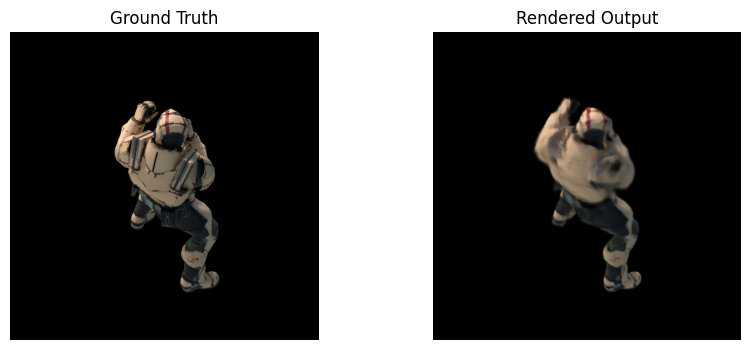

In [71]:
from PIL import Image
import matplotlib.pyplot as plt

gt_path = "output/hook_5000/test/ours_5000/gt/00000.png"
render_path = "output/hook_5000/test/ours_5000/renders/00000.png"

gt = Image.open(gt_path)
render = Image.open(render_path)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gt)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(render)
plt.title("Rendered Output")
plt.axis("off")

plt.show()

## List Available Test Frame Names

This cell lists available ground truth frame filenames so later visualization code can use valid image names instead of assuming file indices.


In [73]:
!ls output/hook_5000/test/ours_5000/gt | head -20

00000.png
00001.png
00002.png
00003.png
00004.png
00005.png
00006.png
00007.png
00008.png
00009.png
00010.png
00011.png
00012.png
00013.png
00014.png
00015.png
00016.png
00017.png
00018.png
00019.png


## Multi-Frame Qualitative Comparison

This cell automatically selects several test frames and compares ground truth images against rendered outputs. Multiple frames help evaluate temporal consistency across the dynamic scene.


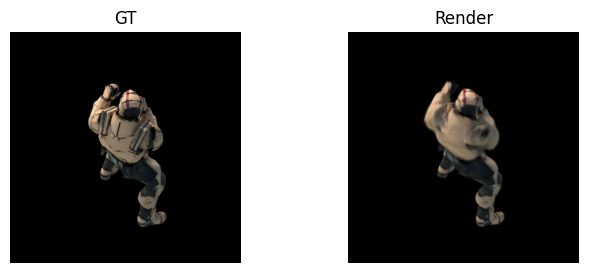

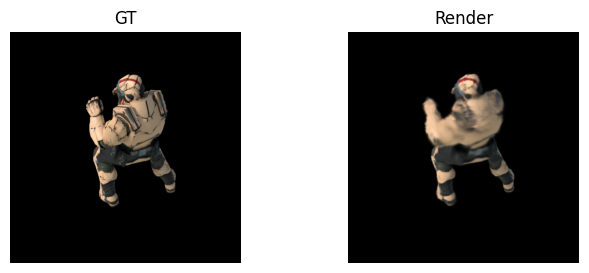

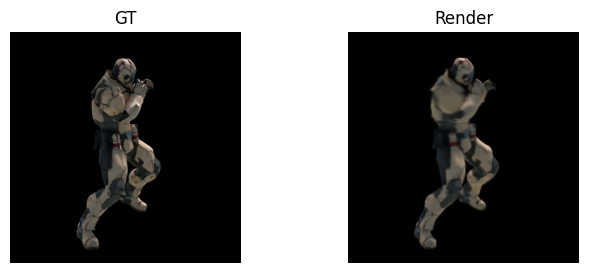

In [74]:
import os
from PIL import Image
import matplotlib.pyplot as plt

gt_dir = "output/hook_5000/test/ours_5000/gt"
render_dir = "output/hook_5000/test/ours_5000/renders"

files = sorted(os.listdir(gt_dir))[:3]  # pick first 3

for f in files:
    gt = Image.open(f"{gt_dir}/{f}")
    render = Image.open(f"{render_dir}/{f}")

    plt.figure(figsize=(8,3))

    plt.subplot(1,2,1)
    plt.imshow(gt)
    plt.title("GT")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(render)
    plt.title("Render")
    plt.axis("off")

    plt.show()

## Render Hook 1000-Iteration Baseline

This cell renders the shorter 1000-iteration `hook_test` model. These images are required for direct visual comparison against the 5000-iteration model.


In [76]:
!python render.py \
  -m output/hook_test \
  --iteration 1000

Looking for config file in output/hook_test/cfg_args
Config file found: output/hook_test/cfg_args
Rendering output/hook_test
Loading trained model at iteration 1000 [24/04 23:46:54]
Found transforms_train.json file, assuming Blender data set! [24/04 23:46:54]
Reading Training Transforms [24/04 23:46:54]
Reading Test Transforms [24/04 23:47:00]
Loading Training Cameras [24/04 23:47:01]
Loading Test Cameras [24/04 23:47:02]
Rendering progress: 100% 100/100 [00:20<00:00,  4.96it/s]
Rendering progress: 100% 100/100 [00:00<00:00, 167.63it/s]
Test FPS: 172.79433, Num. of GS: 6216 [24/04 23:47:24]
Rendering progress: 100% 20/20 [00:03<00:00,  5.35it/s]
Rendering progress: 100% 20/20 [00:00<00:00, 135.93it/s]
Test FPS: 136.53333, Num. of GS: 6216 [24/04 23:47:27]


## Verify Hook 1000-Iteration Render Files

This cell confirms that rendered images were generated for the 1000-iteration hook baseline.


In [77]:
!ls output/hook_test/test/ours_1000/renders | head

00000.png
00001.png
00002.png
00003.png
00004.png
00005.png
00006.png
00007.png
00008.png
00009.png


## Iteration Comparison: 1000 vs 5000

This cell compares the same frame across ground truth, 1000-iteration render, and 5000-iteration render. The comparison demonstrates how longer optimization improves reconstruction sharpness and structure.


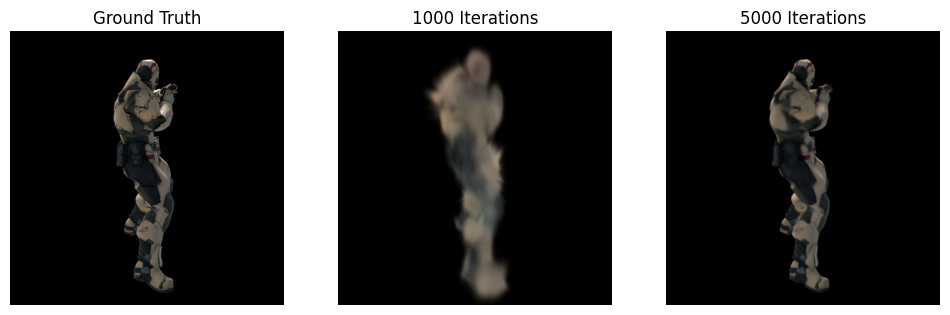

In [78]:
from PIL import Image
import matplotlib.pyplot as plt
f = "00009.png"
gt = Image.open(f"output/hook_5000/test/ours_5000/gt/{f}")
render_1000 = Image.open(f"output/hook_test/test/ours_1000/renders/{f}")
render_5000 = Image.open(f"output/hook_5000/test/ours_5000/renders/{f}")
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(gt)
plt.title("Ground Truth")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(render_1000)
plt.title("1000 Iterations")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(render_5000)
plt.title("5000 Iterations")
plt.axis("off")
plt.show()